In [1]:
import numpy as np
import random
from collections import namedtuple, deque
import math
from matplotlib import pyplot as plt
import matplotlib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [3]:
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

# MDP


In [4]:
from sepsisSimDiabetes.Action import Action
from sepsisSimDiabetes.State import State
from sepsisSimDiabetes.MDP import MDP

# Deep Q-Learning

In [5]:
from dqn import DQN, ReplayBuffer, train_dqn, device, LR

In [6]:
BUFFER_CAPACITY = 10_000
NUM_EPISODES = 1_000
T = 14

In [7]:
policy_net = DQN(n_observations=State.NUM_STATE_VARS,
                 hidden_dim=128,
                 n_actions=Action.NUM_ACTIONS_TOTAL).to(device)
target_net = DQN(n_observations=State.NUM_STATE_VARS,
                 hidden_dim=128,
                 n_actions=Action.NUM_ACTIONS_TOTAL).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayBuffer(BUFFER_CAPACITY)


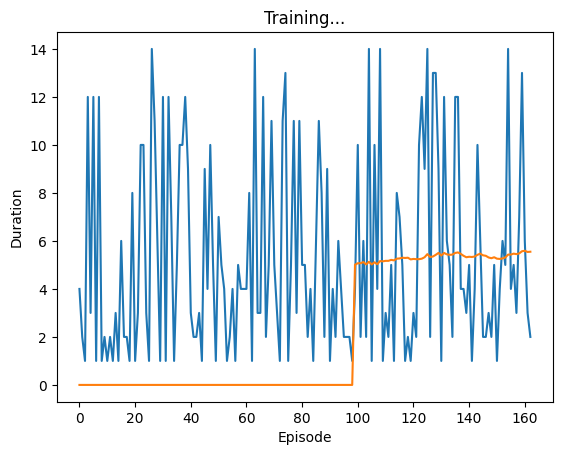

<Figure size 640x480 with 0 Axes>

In [ ]:
final_policy_net, final_target_net = train_dqn(memory, policy_net, target_net, optimizer, NUM_EPISODES, T)